**Run code that proves you're on GCP, and embed your screenshot in the Markdown cell.**

In [1]:
import platform, socket, os
print("Host:", socket.gethostname())
print("Python:", platform.python_version())
!gcloud config list   # shows your active GCP project

Host: 6de74250b1cf
Python: 3.12.13
[component_manager]
disable_update_check = True
[core]
account = ms10766539@sju.edu
project = fabled-decker-510900-u1
universe_domain = googleapis.com

Your active configuration is: [default]
[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.


**Loads Data Set**

In [2]:
import pandas as pd

df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
df = df.dropna(axis=1, how='all')   # remove the empty trailing columns
df = df.dropna(axis=0, how='all')   # remove the empty rows at the bottom
print(df.shape)                     # should be about (9357, 15)

(9357, 15)


**Replace -200 with NaN and count missing values per column, drop NMHC(GT), drop rows where your target is missing, and use SimpleImputer(strategy='median') for the remaining numeric gaps.**

In [3]:
import numpy as np
df = df.replace(-200, np.nan)
print(df.isna().mean().sort_values(ascending=False))

NMHC(GT)         0.902319
CO(GT)           0.179865
NO2(GT)          0.175484
NOx(GT)          0.175163
PT08.S2(NMHC)    0.039115
C6H6(GT)         0.039115
PT08.S1(CO)      0.039115
PT08.S5(O3)      0.039115
T                0.039115
PT08.S3(NOx)     0.039115
PT08.S4(NO2)     0.039115
RH               0.039115
AH               0.039115
Date             0.000000
Time             0.000000
dtype: float64


In [4]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

**Parse date and time into temporal features (CSV format: day first , periods in time)**

In [5]:

df = df.dropna(subset=['Date', 'Time'])
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['Hour'] = df['Datetime'].dt.hour
df['Weekday'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month
print("Date range:", df['Datetime'].min(), "to", df['Datetime'].max())



Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00


**Isolate numerical and categorical/temporal features (no"(GT)" columns)**

In [6]:
num_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)',
            'PT08.S5(O3)', 'T', 'RH', 'AH']
cat_cols = ['Hour', 'Weekday', 'Month']
print("Numerical features:", num_cols)
print("Categorical/temporal features:", cat_cols)


Numerical features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Categorical/temporal features: ['Hour', 'Weekday', 'Month']


**Build the ColumnTransformer (scaler can be swapped)**

In [7]:
def build_preprocessor(scaler=StandardScaler()):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ])

**Quick check to see what the preprocessor produces**

In [8]:
preprocessor = build_preprocessor(StandardScaler())
X_demo = preprocessor.fit_transform(df[num_cols + cat_cols])
print("Transformed shape:", X_demo.shape)
print("Example feature names:", preprocessor.get_feature_names_out()[:12])
preprocessor

Transformed shape: (9357, 51)
Example feature names: ['num__PT08.S1(CO)' 'num__PT08.S2(NMHC)' 'num__PT08.S3(NOx)'
 'num__PT08.S4(NO2)' 'num__PT08.S5(O3)' 'num__T' 'num__RH' 'num__AH'
 'cat__Hour_0' 'cat__Hour_1' 'cat__Hour_2' 'cat__Hour_3']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['PT08.S1(CO)', 'PT08.S2(NMHC)',
                                  'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
                                  'T', 'RH', 'AH']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Hour', 'Weekday', 'Month'])])

Import data

In [9]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.exceptions import ConvergenceWarning

**Create the target classes from CO concentration**

In [10]:
data = df.dropna(subset=['CO(GT)'])
X = data[num_cols + cat_cols]
y, bins = pd.qcut(data['CO(GT)'], q=3, labels=[0, 1, 2], retbins=True)
print("Bin edges (mg/m³):", bins.round(2))
print("Class counts:\n", y.value_counts().sort_index())

Bin edges (mg/m³): [ 0.1  1.3  2.4 11.9]
Class counts:
 CO(GT)
0    2623
1    2506
2    2545
Name: count, dtype: int64


**Train/test split (stratified so each class keeps its proportion)**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

**softmax regression vs. SGD with custom losses and hyperparameters**

In [12]:
models = {
    'Softmax (LogisticRegression)': LogisticRegression(max_iter=1000),
    'SGD log_loss': SGDClassifier(loss='log_loss', alpha=1e-4, max_iter=1000, random_state=42),
    'SGD modified_huber': SGDClassifier(loss='modified_huber', alpha=1e-4, max_iter=1000, random_state=42),
    'SGD hinge': SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1000, random_state=42),
    'SGD log_loss (constant lr=0.01)': SGDClassifier(loss='log_loss', learning_rate='constant',
                                                     eta0=0.01, max_iter=1000, random_state=42),
}

**Train and evaluate each model with both scalers**

In [13]:
results, fitted = [], {}
for scaler_name, scaler in [('Standard', StandardScaler()), ('MinMax', MinMaxScaler())]:
    for name, model in models.items():
        pipe = Pipeline([('prep', build_preprocessor(scaler)), ('clf', model)])

        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter('always', ConvergenceWarning)
            start = time.time()
            pipe.fit(X_train, y_train)
            train_time = time.time() - start
            converged = not any(issubclass(x.category, ConvergenceWarning) for x in w)

        y_pred = pipe.predict(X_test)
        auc = (roc_auc_score(y_test, pipe.predict_proba(X_test), multi_class='ovr')
               if hasattr(pipe, 'predict_proba') else np.nan)

        results.append({
            'scaler': scaler_name, 'model': name,
            'accuracy': accuracy_score(y_test, y_pred),
            'macro_f1': f1_score(y_test, y_pred, average='macro'),
            'roc_auc': auc,
            'iterations': int(np.max(pipe.named_steps['clf'].n_iter_)),
            'converged': converged,
            'train_time_sec': train_time,
        })
        fitted[(scaler_name, name)] = pipe

results_df = pd.DataFrame(results).round(4)
display(results_df)

,scaler,model,accuracy,macro_f1,roc_auc,iterations,converged,train_time_sec
0,Standard,Softmax (LogisticRegression),0.8619,0.8617,0.9638,51,True,0.1668
1,Standard,SGD log_loss,0.8345,0.8317,0.9414,52,True,0.1307
2,Standard,SGD modified_huber,0.8202,0.8132,0.9316,120,True,0.1751
3,Standard,SGD hinge,0.8371,0.8333,NaN,70,True,0.0997
4,Standard,SGD log_loss (constant lr=0.01),0.8443,0.8417,0.9473,15,True,0.0595
5,MinMax,Softmax (LogisticRegression),0.8528,0.8526,0.9615,64,True,0.1840
6,MinMax,SGD log_loss,0.8261,0.8246,0.9433,44,True,0.1140
7,MinMax,SGD modified_huber,0.8195,0.8226,0.9423,83,True,0.1115
8,MinMax,SGD hinge,0.8169,0.8099,NaN,44,True,0.0663
9,MinMax,SGD log_loss (constant lr=0.01),0.8202,0.8126,0.9341,27,True,0.0808


**Detailed report and confusion matrix for the best model**


Best model: Softmax (LogisticRegression) with Standard scaler
              precision    recall  f1-score   support

         Low       0.55      0.99      0.71       525
    Moderate       0.69      0.11      0.20       501
        High       0.86      0.86      0.86       509

    accuracy                           0.66      1535
   macro avg       0.70      0.65      0.59      1535
weighted avg       0.70      0.66      0.59      1535



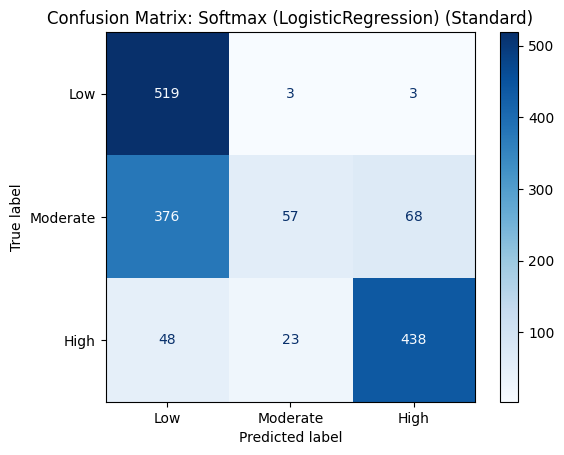

In [14]:
best = results_df.sort_values('macro_f1', ascending=False).iloc[0]
best_pipe = fitted[(best['scaler'], best['model'])]
print(f"\nBest model: {best['model']} with {best['scaler']} scaler")
print(classification_report(y_test, best_pipe.predict(X_test),
                            target_names=['Low', 'Moderate', 'High']))

ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test,
                                      display_labels=['Low', 'Moderate', 'High'], cmap='Blues')
plt.title(f"Confusion Matrix: {best['model']} ({best['scaler']})")
plt.show()

**Convergence comparison chart**

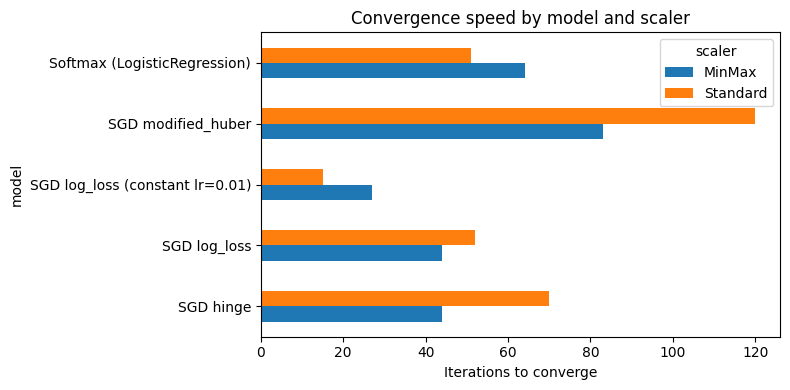

In [15]:
results_df.pivot(index='model', columns='scaler', values='iterations').plot(kind='barh', figsize=(8, 4))
plt.xlabel('Iterations to converge')
plt.title('Convergence speed by model and scaler')
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

**Regression target: benzene concentration (drop rows where it's missing)**

In [17]:
target = 'C6H6(GT)'
reg_data = df.dropna(subset=[target])
X = reg_data[num_cols + cat_cols]
y = reg_data[target]
print(f"Rows used: {len(reg_data)}  |  Target range: {y.min():.1f} to {y.max():.1f} µg/m³")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(pipe):
    pred = pipe.predict(X_test)
    return {'r2': r2_score(y_test, pred),
            'rmse': np.sqrt(mean_squared_error(y_test, pred)),
            'mae': mean_absolute_error(y_test, pred)}


Rows used: 8991  |  Target range: 0.1 to 63.7 µg/m³


**Baseline Linear Regression**

In [18]:
baseline = Pipeline([('prep', build_preprocessor(StandardScaler())), ('reg', LinearRegression())])
baseline.fit(X_train, y_train)
feature_names = baseline.named_steps['prep'].get_feature_names_out()
results = [{'model': 'Linear Regression', 'alpha': None, **evaluate(baseline),
            'zero_coefs': int(np.sum(np.isclose(baseline.named_steps['reg'].coef_, 0)))}]

**Ridge and Lasso across a range of alphas**

In [19]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coefs = {'Ridge': [], 'Lasso': []}

for name, Model in [('Ridge', Ridge), ('Lasso', Lasso)]:
    for a in alphas:
        model = Model(alpha=a, max_iter=10000) if name == 'Lasso' else Model(alpha=a)
        pipe = Pipeline([('prep', build_preprocessor(StandardScaler())), ('reg', model)])
        pipe.fit(X_train, y_train)
        c = pipe.named_steps['reg'].coef_
        coefs[name].append(c)
        results.append({'model': name, 'alpha': a, **evaluate(pipe),
                        'zero_coefs': int(np.sum(np.isclose(c, 0)))})

results_df = pd.DataFrame(results).round(4)
display(results_df)

,model,alpha,r2,rmse,mae,zero_coefs
0,Linear Regression,NaN,0.9795,1.0841,0.7635,0
1,Ridge,0.001,0.9795,1.0841,0.7637,0
2,Ridge,0.010,0.9795,1.0841,0.7637,0
3,Ridge,0.100,0.9795,1.0840,0.7636,0
4,Ridge,1.000,0.9796,1.0840,0.7630,0
5,Ridge,10.000,0.9795,1.0858,0.7600,0
6,Ridge,100.000,0.9766,1.1599,0.7919,0
7,Lasso,0.001,0.9796,1.0840,0.7613,4
8,Lasso,0.010,0.9781,1.1206,0.7824,21
9,Lasso,0.100,0.9706,1.3002,0.9107,45


**Coefficient paths for the numerical (sensor and weather) features**

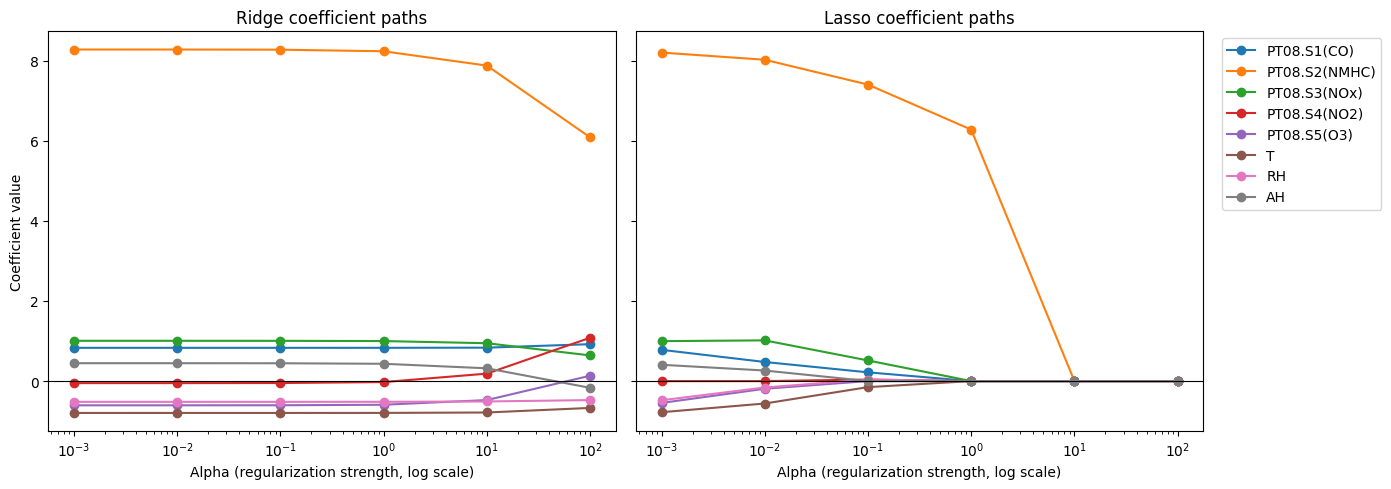

In [20]:
num_idx = [i for i, f in enumerate(feature_names) if f.startswith('num__')]
num_names = [feature_names[i].replace('num__', '') for i in num_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name in zip(axes, ['Ridge', 'Lasso']):
    path = np.array(coefs[name])[:, num_idx]
    for j, fname in enumerate(num_names):
        ax.plot(alphas, path[:, j], marker='o', label=fname)
    ax.set_xscale('log')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Alpha (regularization strength, log scale)')
    ax.set_title(f'{name} coefficient paths')
axes[0].set_ylabel('Coefficient value')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Lasso feature selection: how many features remain as alpha increases**

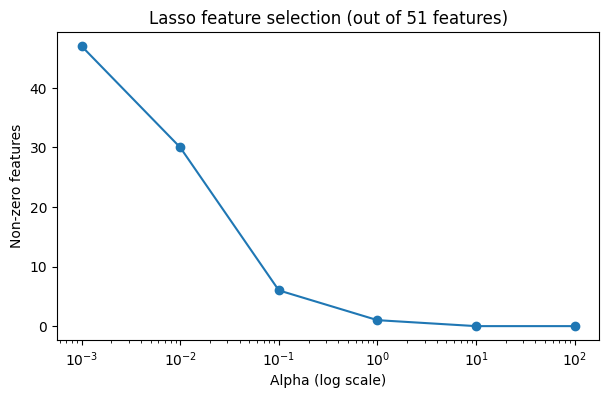

In [21]:
total = len(feature_names)
plt.figure(figsize=(7, 4))
plt.plot(alphas, [total - np.sum(np.isclose(c, 0)) for c in coefs['Lasso']], marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Non-zero features')
plt.title(f'Lasso feature selection (out of {total} features)')
plt.show()

**Side-by-side coefficients at a moderate alpha (alpha =1)**

In [22]:
i = alphas.index(1)
coef_table = pd.DataFrame({
    'feature': [f.replace('num__', '').replace('cat__', '') for f in feature_names],
    'linear': baseline.named_steps['reg'].coef_,
    'ridge (α=1)': coefs['Ridge'][i],
    'lasso (α=1)': coefs['Lasso'][i],
}).round(3)
print("Features Lasso kept at alpha = 1:")
display(coef_table[coef_table['lasso (α=1)'] != 0]
        .sort_values('lasso (α=1)', key=abs, ascending=False))

Features Lasso kept at alpha = 1:


,feature,linear,ridge (α=1),lasso (α=1)
1,PT08.S2(NMHC),8.277,8.235,6.279


**Billing Credits and report**

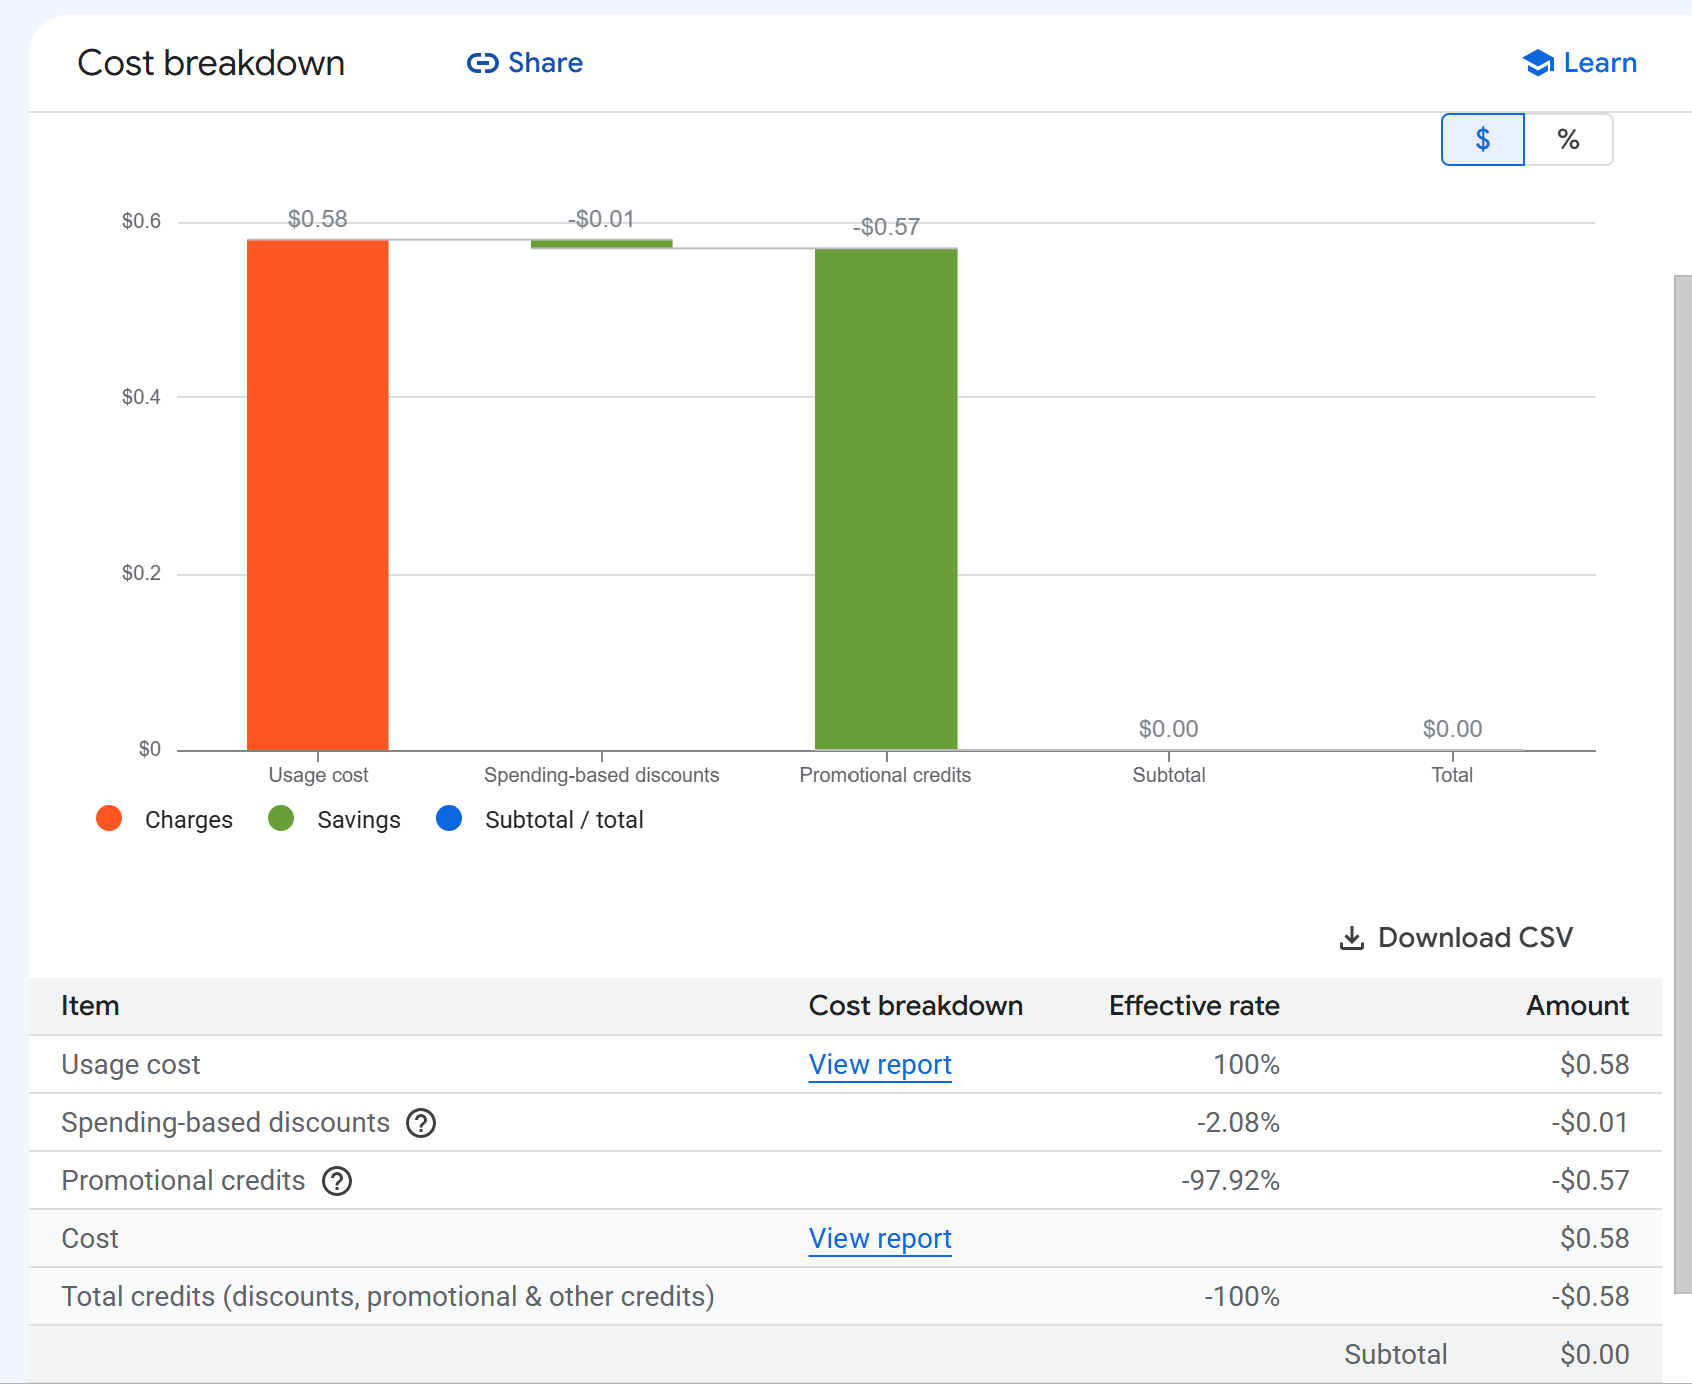

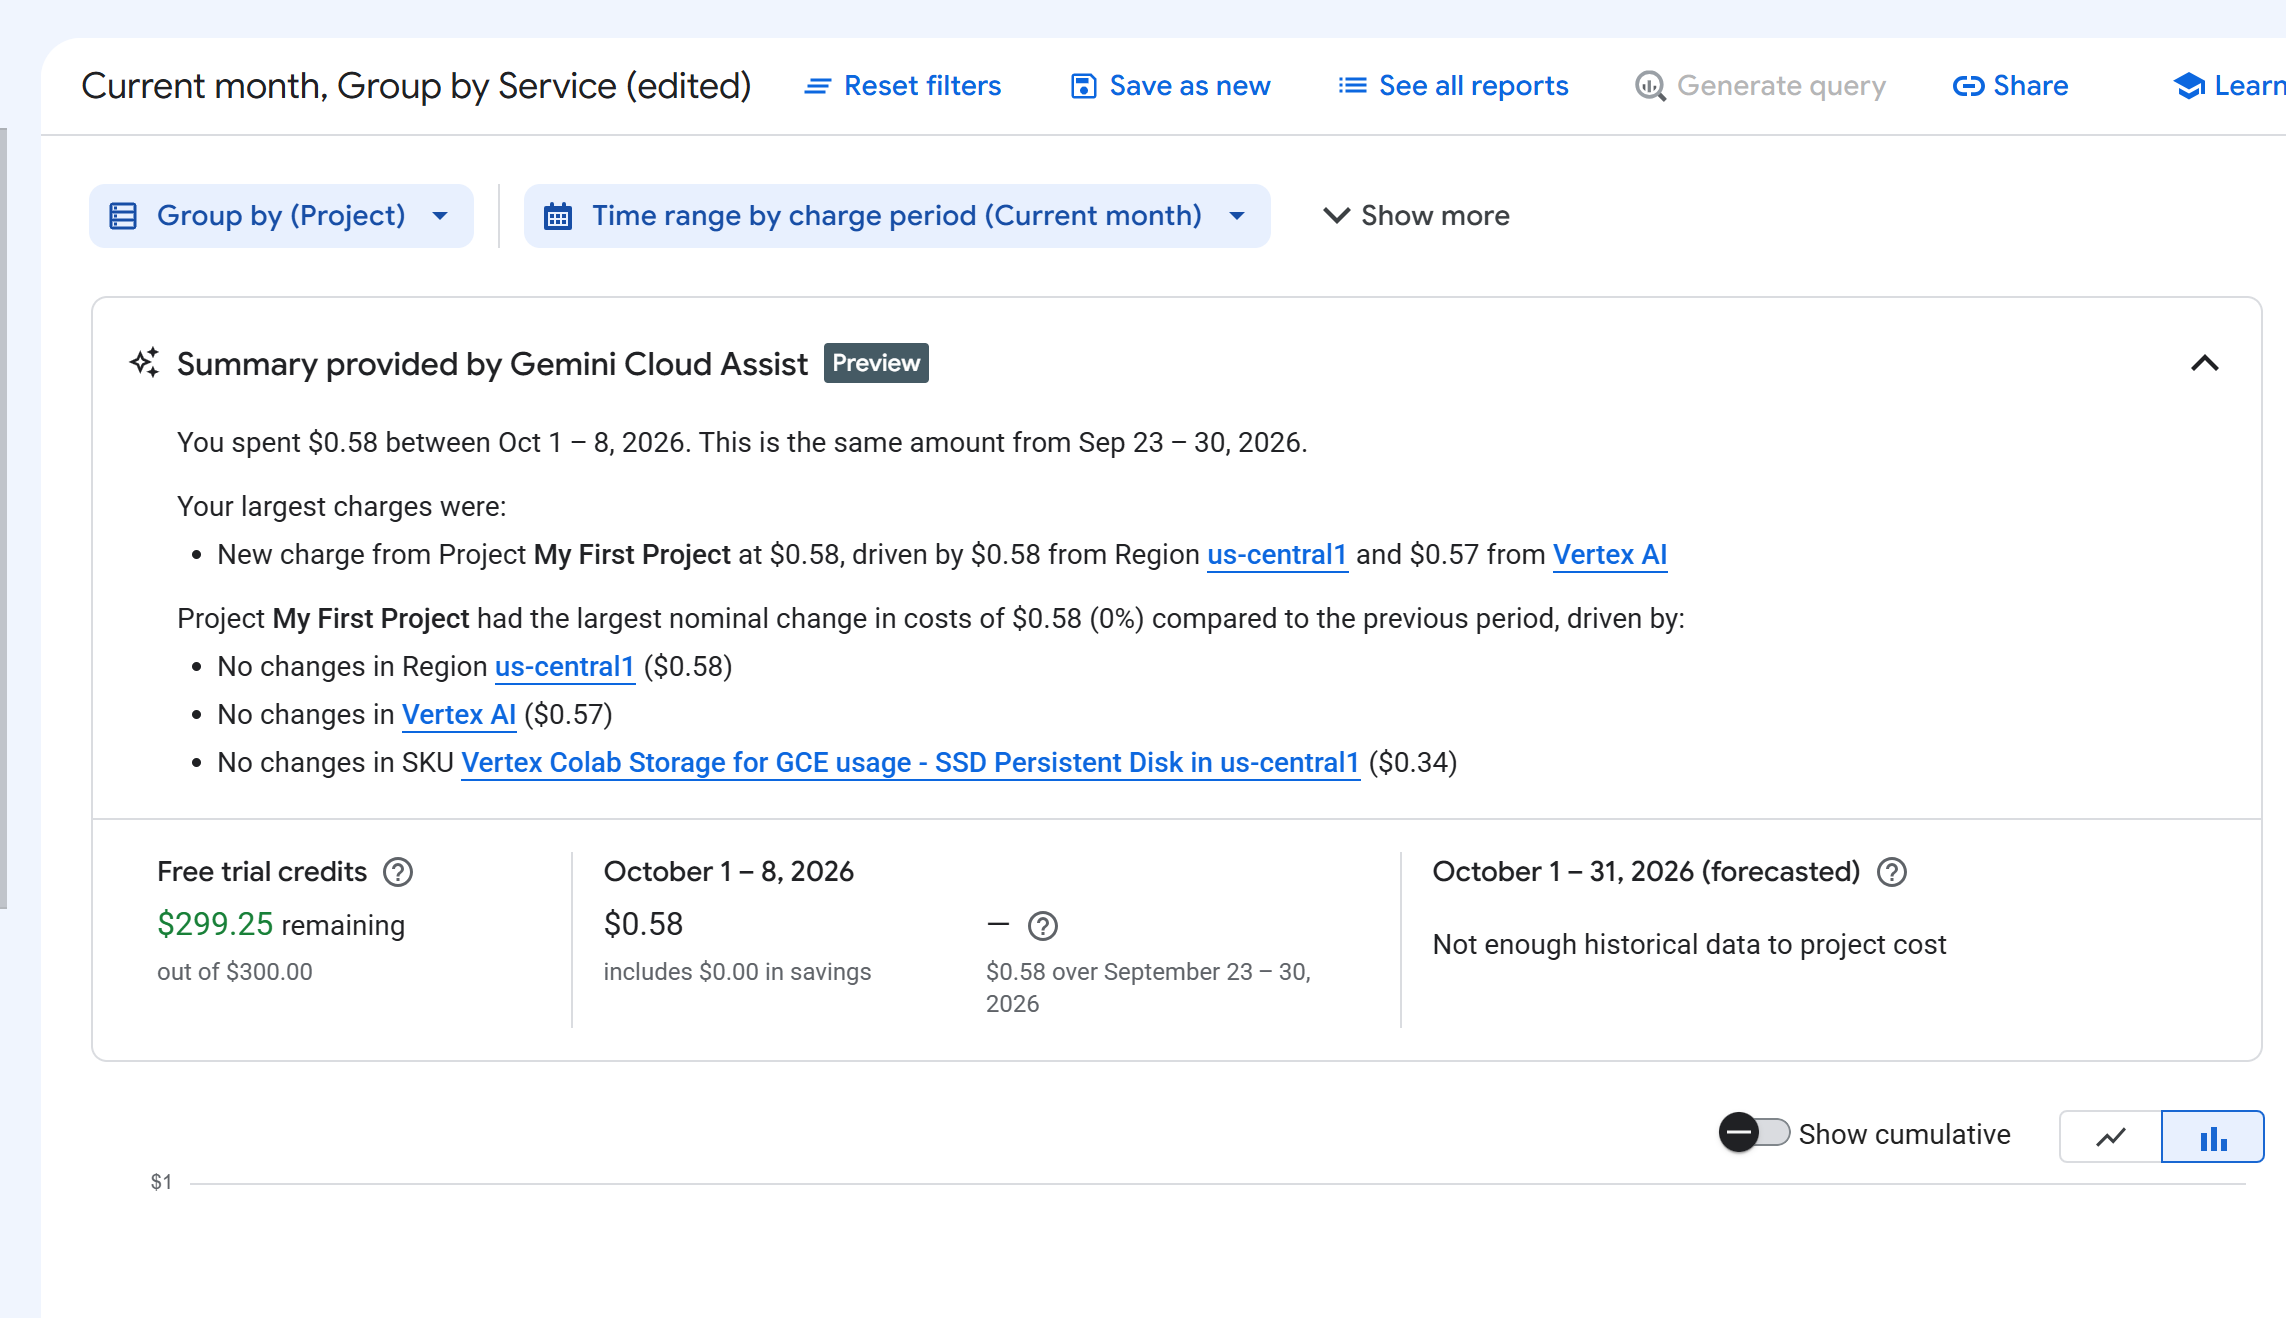

In [24]:
from IPython.display import Image, display

display(Image(filename='billing_credits.png', width=900))
display(Image(filename='billing_report.png', width=900))